# 股票指标
- 极差：`np.ptp`
- VWAP: `np.average(..., weights = ...)`
- 方差：`np.var()`
- 均线：`np.convolve()`

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
import pandas as pd

plt.rcParams['figure.dpi'] =  300    #分辨率


end price: [ 9.71 10.3   9.99  9.6   9.85  9.86  9.47 10.2  10.3  10.62 11.11 11.36
 11.79 11.79 11.64 11.66 11.95 13.04 12.8  13.19]
volumn [ 340827.  635330.  611960.  392572.  604457.  415480. 1730708.  765325.
  895014.  664370.  936335.  472975.  824456.  469410.  345713.  329749.
  368640.  540952.  373428.  324698.]
max - min of high_price: 3.8099999999999987
max - min of low_price: 3.9399999999999995
ave_price: 11.0115
VWAP: 10.768422980338055
var: 1.3352127499999997
对数波动率： [ 0.05898761 -0.0305593  -0.03982149  0.02570836  0.00101471 -0.04035726
  0.07425881  0.00975617  0.03059512  0.04510659  0.02225281  0.0371533
  0.         -0.01280427  0.00171674  0.0245671   0.08729028 -0.01857639
  0.0300138 ]
年度波动率： 0.5553989853138551
月度波动率： 0.12168182106875156


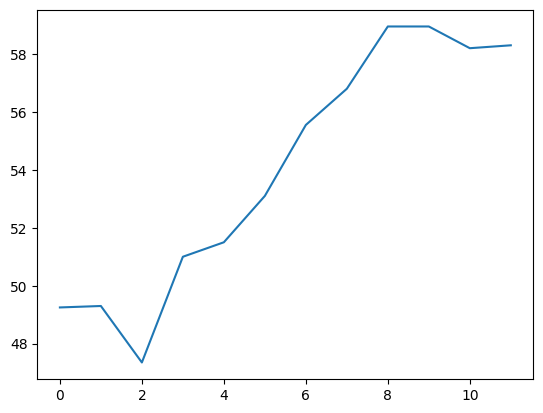

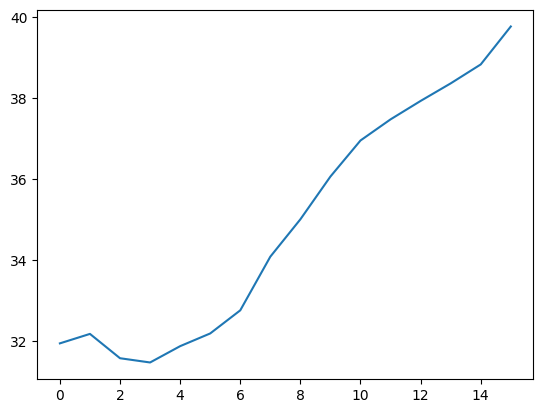

In [ ]:


# np.loadtxt 读取数据文件
path = "data.csv"
end_price, volumn = np.loadtxt(
    fname=path, 
    delimiter=',', 
    usecols = (2,6),
    unpack=True)
print("end price:",end_price)
print("volumn",volumn)



# 计算极差 np.ptp
high_price, low_price= np.loadtxt(
    fname=path, 
    delimiter=',', 
    usecols = (4,5),
    unpack=True)
print("max - min of high_price:",np.ptp(high_price))
print("max - min of low_price:", np.ptp(low_price))


# 计算VWAP
print("ave_price:", np.average(end_price))
print("VWAP:", np.average(end_price, weights=volumn))


# 计算方差
print("var:", np.var(end_price))

# 计算益率
log_return = np.diff(np.log(end_price))
print("对数波动率：",log_return)
print("年度波动率：", log_return.std() * np.sqrt(250))
print("月度波动率：", log_return.std() * np.sqrt(12))

# 计算均线
## 简单移动均线
N = 5
weights = N
sma = np.convolve(weights, end_price)[N-1:-N+1]
plt.plot(sma)
plt.show()

## 指数移动均线
N = 5
weights = np.exp(np.linspace(-1., 0., N))
ema = np.convolve(weights, end_price)[N-1:-N+1]
plt.plot(ema)
plt.show()


## 绘制K线图

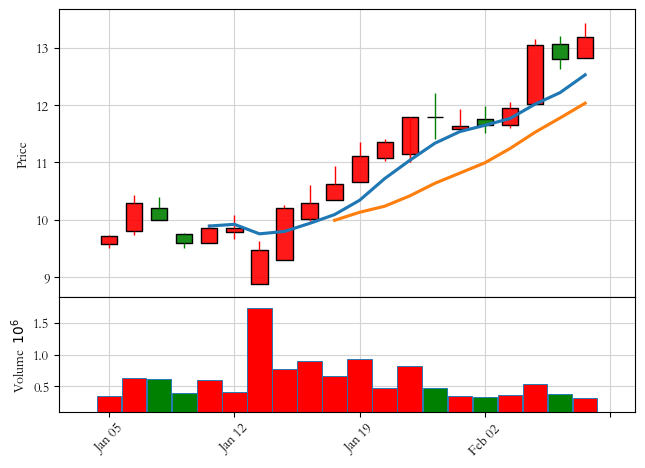

In [48]:
'''
原教程中的mpl_finance 以弃用，改用 mplfinance 库
'''
# np.loadtxt 读取数据文件
path = "data.csv"
df = pd.read_csv(path, header=None,
                 names=['stock_id', 'date', 'close', 'open', 'high', 'low', 'volume'],
                 parse_dates=['date'],  # 自动解析日期列
                 index_col='date')       # 将日期列设置为索引列
# 自定义涨跌颜色
mc = mpf.make_marketcolors(
    up     = 'red',      # 上涨K线颜色（阳线）
    down   = 'green',  # 下跌K线颜色（阴线）
    # edge   = 'black',   # K线边框颜色，'inherit'表示与主体颜色一致
    wick   = 'inherit',   # 影线颜色，'inherit'表示与主体颜色一致
    volume = 'inherit'   # 成交量柱颜色
)
# 将颜色配置应用到样式中
custom_style = mpf.make_mpf_style(
    marketcolors = mc,           # 使用上面定义的颜色
    gridaxis     = 'both',           # 网格线
    gridcolor    = 'lightgray',      # 网格线颜色
    rc           = {'font.family':'STSong'}
)
mpf.plot(df, 
        mav=(5, 10, 20), # 多条均线：5日、10日、20日
        type='candle', style=custom_style, volume=True)

In [25]:
pd.read_csv('data.csv',names=['stock_id', 'date', 'close', 'open' ,'high', 'low', 'volume'])

,stock_id,date,close,open,high,low,volume
0,000001.SZ,2009/1/5,9.71,9.57,9.740,9.51,340827
1,000001.SZ,2009/1/6,10.30,9.80,10.430,9.73,635330
2,000001.SZ,2009/1/7,9.99,10.20,10.400,9.99,611960
3,000001.SZ,2009/1/8,9.60,9.75,9.760,9.50,392572
4,000001.SZ,2009/1/9,9.85,9.60,9.930,9.60,604457
5,000001.SZ,2009/1/12,9.86,9.78,10.080,9.67,415480
6,000001.SZ,2009/1/13,9.47,8.88,9.630,8.88,1730708
7,000001.SZ,2009/1/14,10.20,9.30,10.250,9.30,765325
8,000001.SZ,2009/1/15,10.30,10.01,10.600,9.97,895014
9,000001.SZ,2009/1/16,10.62,10.34,10.940,10.34,664370
